In [360]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [361]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [362]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/datasets/insurance.csv')

# EDA

In [363]:
df.shape

(1338, 7)

In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [365]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [366]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [367]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

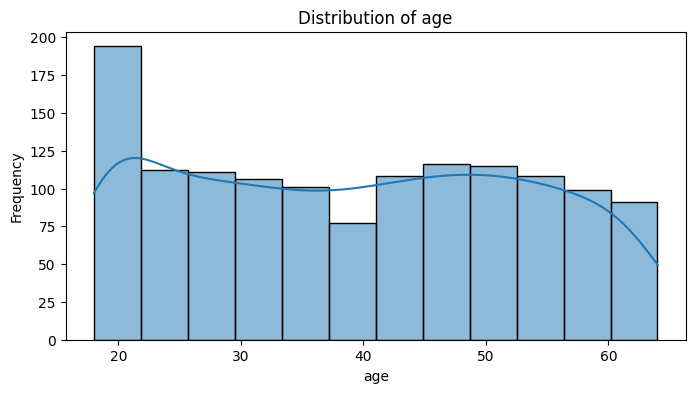

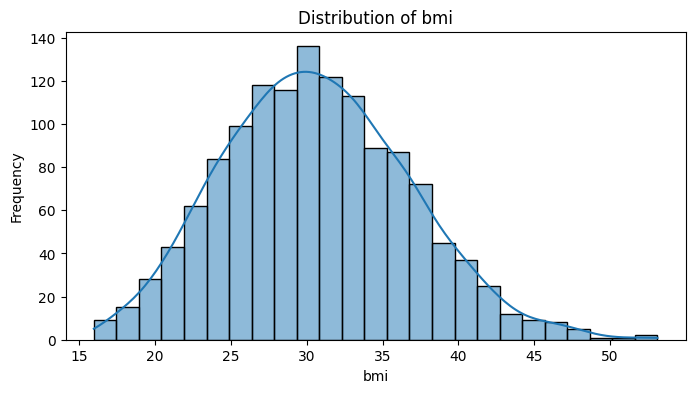

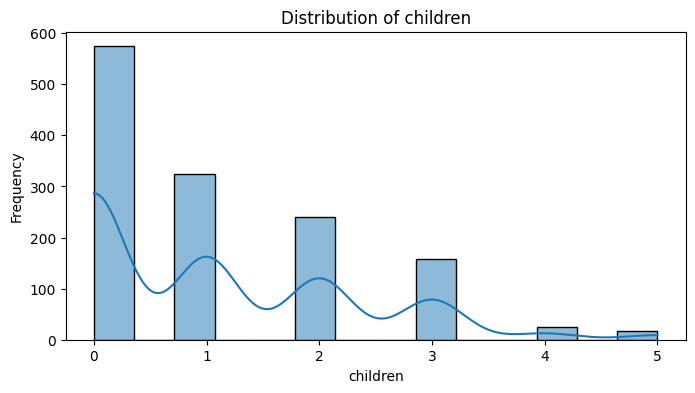

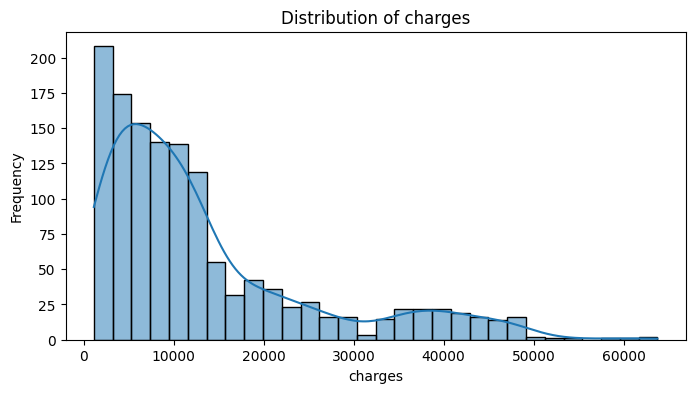

In [368]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

<Axes: xlabel='children', ylabel='count'>

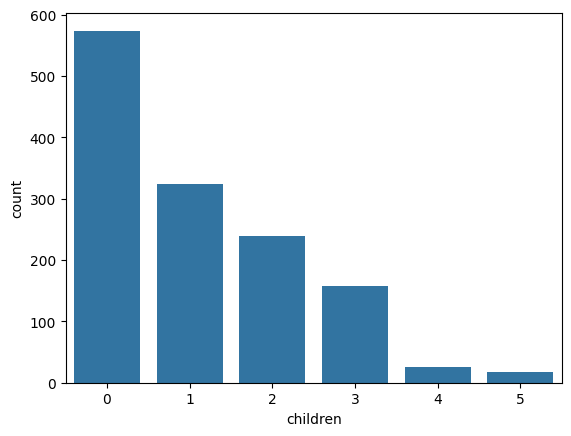

In [369]:
sns.countplot(x='children', data=df)

<Axes: xlabel='sex', ylabel='count'>

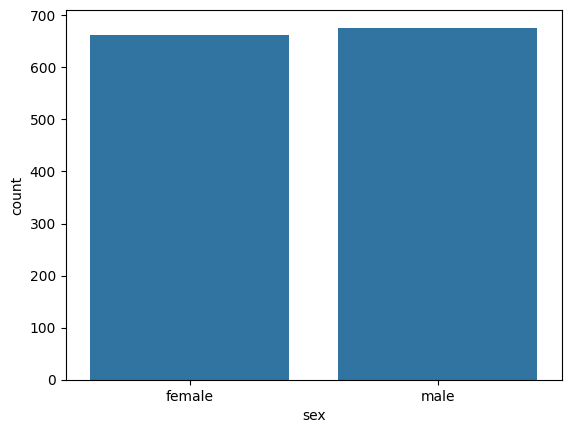

In [370]:
sns.countplot(x='sex', data=df)

<Axes: xlabel='smoker', ylabel='count'>

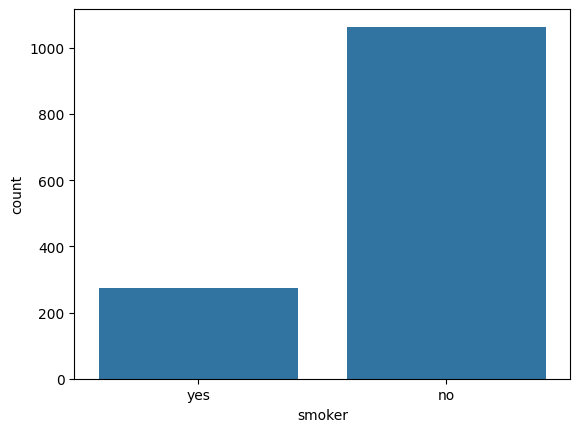

In [371]:
sns.countplot(x='smoker', data=df)

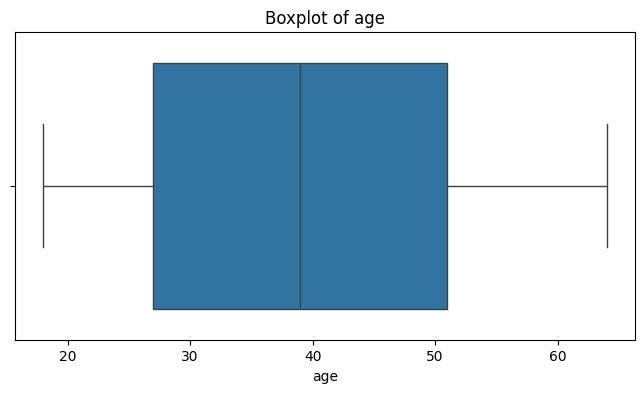

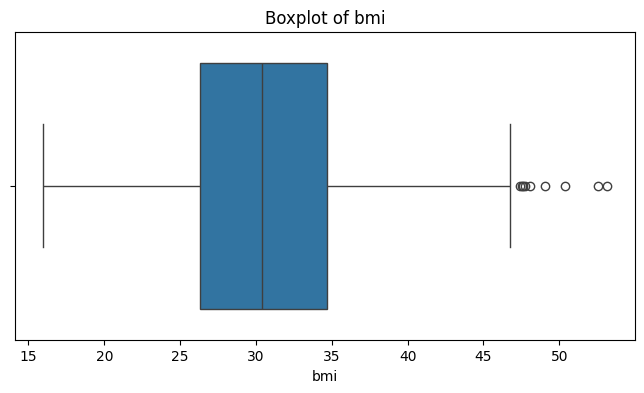

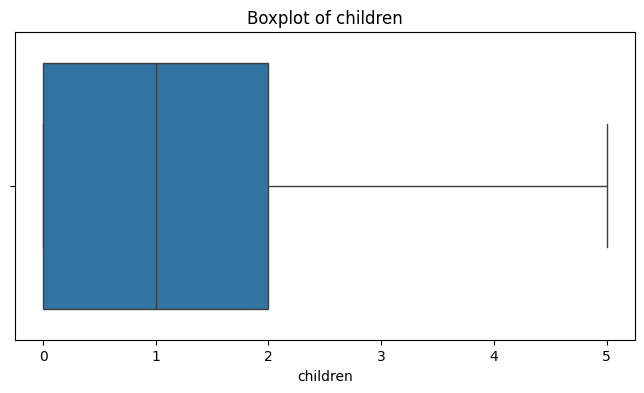

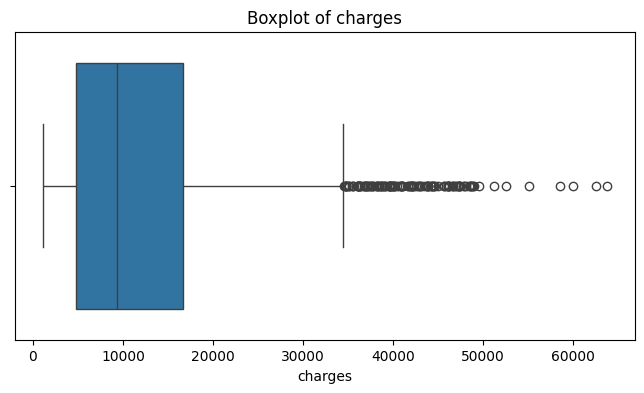

In [372]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

<Axes: >

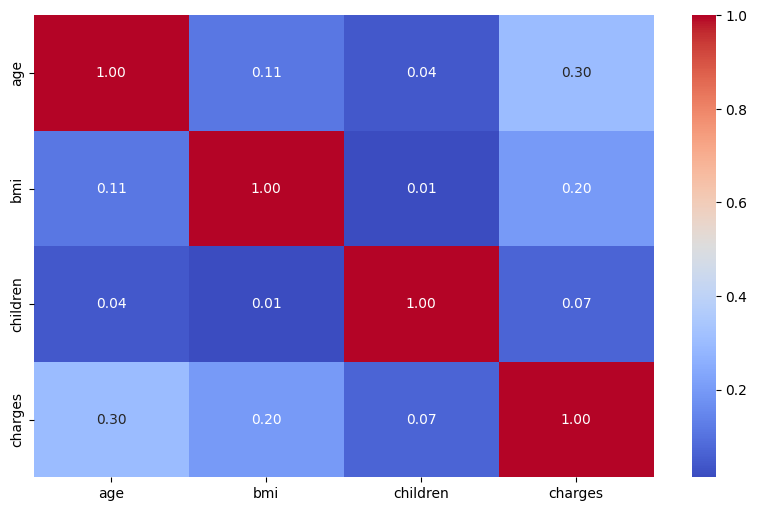

In [373]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

# Data Cleaning and Processing

In [374]:
df_cleaned = df.copy()
df_cleaned.shape

(1338, 7)

In [375]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [376]:
df_cleaned.isnull().sum() 

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [377]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [378]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [379]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0, 'female':1})


In [380]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes': 1, 'no': 0})


In [381]:
df_cleaned.rename(columns={'sex': 'is_female', 'smoker': 'is_smoker'}, inplace=True)
df_cleaned.head()


,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [382]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [383]:
df_cleaned=pd.get_dummies(df_cleaned, columns=['region'])

In [384]:
df_cleaned=df_cleaned.astype(int)

In [385]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


# Feature Engineering and Extraction 
# Scaling encoding labling

<Axes: xlabel='bmi', ylabel='Count'>

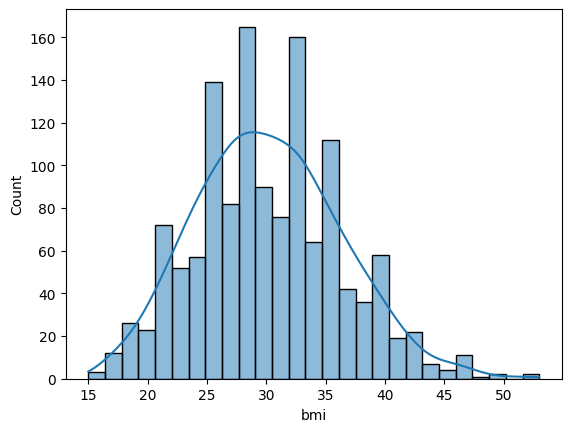

In [386]:
sns.histplot(df_cleaned['bmi'], kde=True)

In [387]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'], bins=[0, 18.5, 24.9, 29.9, np.inf], labels=['Underweight', 'Normal weight', 'Overweight', 'Obese'])

In [388]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,Overweight
1,18,0,33,1,0,1725,0,0,1,0,Obese
2,28,0,33,3,0,4449,0,0,1,0,Obese
3,33,0,22,0,0,21984,0,1,0,0,Normal weight
4,32,0,28,0,0,3866,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,Obese
1334,18,1,31,0,0,2205,1,0,0,0,Obese
1335,18,1,36,0,0,1629,0,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,0,1,Overweight


In [389]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'])


In [390]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,False,False,False,True
1334,18,1,31,0,0,2205,1,0,0,0,False,False,False,True
1335,18,1,36,0,0,1629,0,0,1,0,False,False,False,True
1336,21,1,25,0,0,2007,0,0,0,1,False,False,True,False


In [391]:
df_cleaned=df_cleaned.astype(int)
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,0,1,0


In [392]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight',
       'bmi_category_Normal weight', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='object')

In [393]:
from sklearn.preprocessing import StandardScaler
cols=['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0


In [395]:
# pearson correlation
from scipy.stats import pearsonr

#List of features to check correlation with target variable 'charges'
features = ['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obese'] 

correlations = {}
for feature in features:
    corr, _ = pearsonr(df_cleaned[feature], df_cleaned['charges'])
    correlations[feature] = corr  
    
correlations_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation with Charges'])

correlations_df.sort_values(by='Pearson Correlation with Charges', ascending=False, inplace=True)
correlations_df

,Feature,Pearson Correlation with Charges
4,is_smoker,0.787234
0,age,0.298309
12,bmi_category_Obese,0.200348
1,bmi,0.196236
7,region_southeast,0.073577
2,children,0.067390
5,region_northeast,0.005946
6,region_northwest,-0.038695
8,region_southwest,-0.043637
9,bmi_category_Underweight,-0.050599


In [397]:
# chai quare test for categorical features
from scipy.stats import chi2_contingency
categorical_features = ['is_female', 'is_smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal weight', 'bmi_category_Overweight', 'bmi_category_Obese']

alpha = 0.05
for feature in categorical_features:    
    contingency_table = pd.crosstab(df_cleaned[feature], df_cleaned['charges'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    if p < alpha:
        print(f"{feature} is significantly associated with charges (p-value: {p})")
    else:
        print(f"{feature} is not significantly associated with charges (p-value: {p})") 
        
        


is_female is not significantly associated with charges (p-value: 0.21339802542895192)
is_smoker is not significantly associated with charges (p-value: 0.17195109953451468)
region_northeast is not significantly associated with charges (p-value: 0.2598404871213054)
region_northwest is not significantly associated with charges (p-value: 0.37249194571296623)
region_southeast is not significantly associated with charges (p-value: 0.35199703513118186)
region_southwest is not significantly associated with charges (p-value: 0.5403067725116529)
bmi_category_Underweight is not significantly associated with charges (p-value: 0.7276066151218578)
bmi_category_Normal weight is not significantly associated with charges (p-value: 0.307246799571383)
bmi_category_Overweight is not significantly associated with charges (p-value: 0.32571711870874337)
bmi_category_Obese is not significantly associated with charges (p-value: 0.3288765053882299)


In [398]:
final_df = df_cleaned[['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region_southeast', 'bmi_category_Underweight', 'charges']]

In [399]:
final_df.head()

,age,bmi,children,is_female,is_smoker,region_southeast,bmi_category_Underweight,charges
0,-1.440418,-0.517949,-0.909234,1,1,0,0,16884
1,-1.511647,0.462463,-0.079442,0,0,1,0,1725
2,-0.799350,0.462463,1.580143,0,0,1,0,4449
3,-0.443201,-1.334960,-0.909234,0,0,0,0,21984
4,-0.514431,-0.354547,-0.909234,0,0,0,0,3866
